# 📉 Telecom Customer Churn Prediction
**Goal:** Predict which high-value telecom customers are likely to churn, and identify the key drivers behind churn.

**Strategy:**
- Model 1: Logistic Regression + PCA (dimensionality reduction)
- Model 2: Random Forest (best performance + feature importance)
- Model 3: Random Forest with Class Balancing (improved recall)
- Model 4: Logistic Regression with Threshold Tuning (maximized recall)

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_score, recall_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Load & Preprocess Data

In [2]:
df = pd.read_csv('train.csv')

print(f'Dataset shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nTarget distribution:')
print(df['churn_probability'].value_counts())
print(f'\nChurn rate: {df["churn_probability"].mean()*100:.1f}%')

Dataset shape: (69999, 172)
Missing values: 1835086

Target distribution:
churn_probability
0    62867
1     7132
Name: count, dtype: int64

Churn rate: 10.2%


In [3]:
# Fill missing values with column median (robust to outliers)
df.fillna(df.median(numeric_only=True), inplace=True)

# Keep only numeric features
X = df.drop(columns=['churn_probability'])
y = df['churn_probability']
numeric_cols = X.select_dtypes(include=['int', 'float']).columns
X = X[numeric_cols]

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Features used: {X_train.shape[1]}')

Train size: 48999 | Test size: 21000
Features used: 162


## 3. Exploratory Data Analysis (EDA)

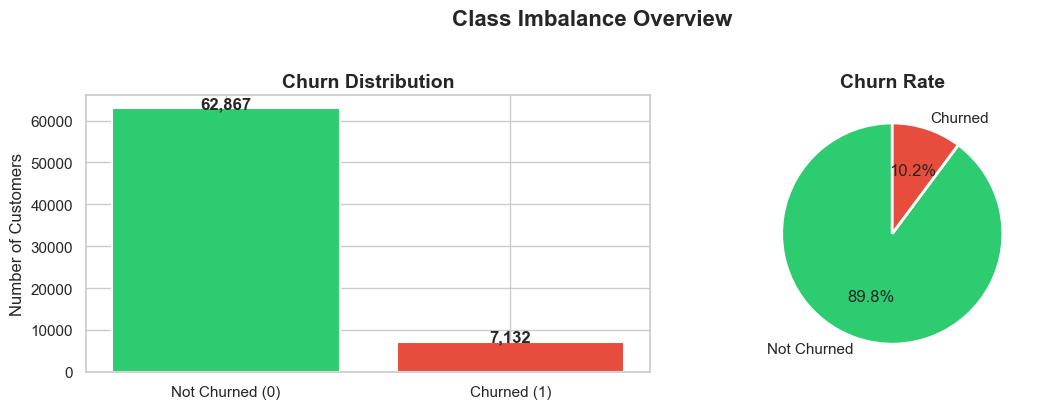


⚠️  Class imbalance: 10.2% churners — this is why recall suffers!


In [4]:
# ── 3.1 Churn Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = y.value_counts()
axes[0].bar(['Not Churned (0)', 'Churned (1)'], churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'\n⚠️  Class imbalance: {churn_counts[1]/len(y)*100:.1f}% churners — this is why recall suffers!')

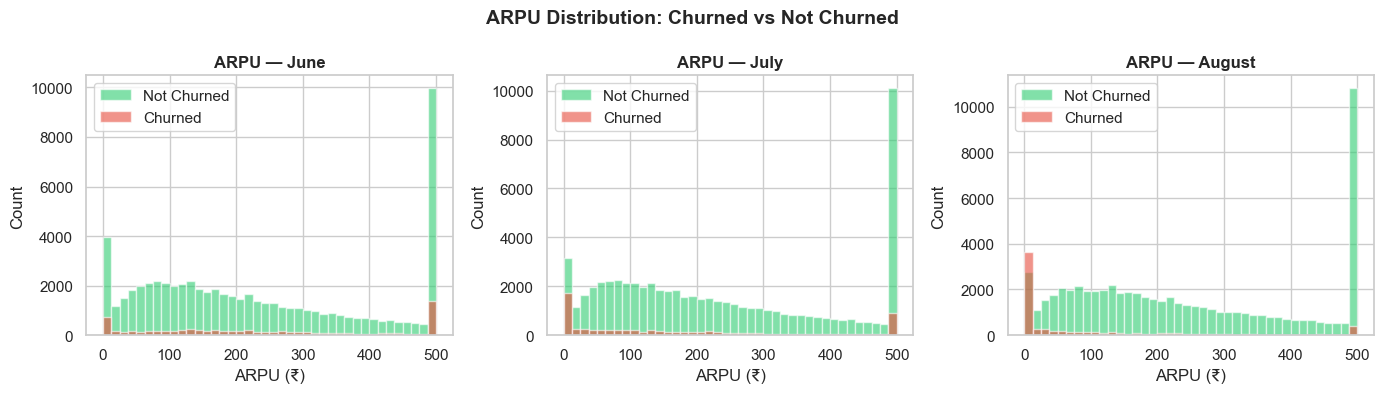

💡 Insight: Churned customers tend to have lower ARPU — declining revenue is an early churn signal.


In [5]:
# ── 3.2 ARPU Distribution by Churn ──────────────────────────────────
# ARPU = Average Revenue Per User — a key business metric
arpu_cols = ['arpu_6', 'arpu_7', 'arpu_8']
existing_arpu = [c for c in arpu_cols if c in df.columns]

if existing_arpu:
    fig, axes = plt.subplots(1, len(existing_arpu), figsize=(14, 4))
    if len(existing_arpu) == 1:
        axes = [axes]
    month_labels = {'arpu_6': 'June', 'arpu_7': 'July', 'arpu_8': 'August'}

    for ax, col in zip(axes, existing_arpu):
        for churn_val, color, label in [(0, '#2ecc71', 'Not Churned'), (1, '#e74c3c', 'Churned')]:
            data = df[df['churn_probability'] == churn_val][col].clip(0, 500)
            ax.hist(data, bins=40, alpha=0.6, color=color, label=label, edgecolor='white')
        ax.set_title(f'ARPU — {month_labels.get(col, col)}', fontweight='bold')
        ax.set_xlabel('ARPU (₹)')
        ax.set_ylabel('Count')
        ax.legend()

    plt.suptitle('ARPU Distribution: Churned vs Not Churned', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('💡 Insight: Churned customers tend to have lower ARPU — declining revenue is an early churn signal.')

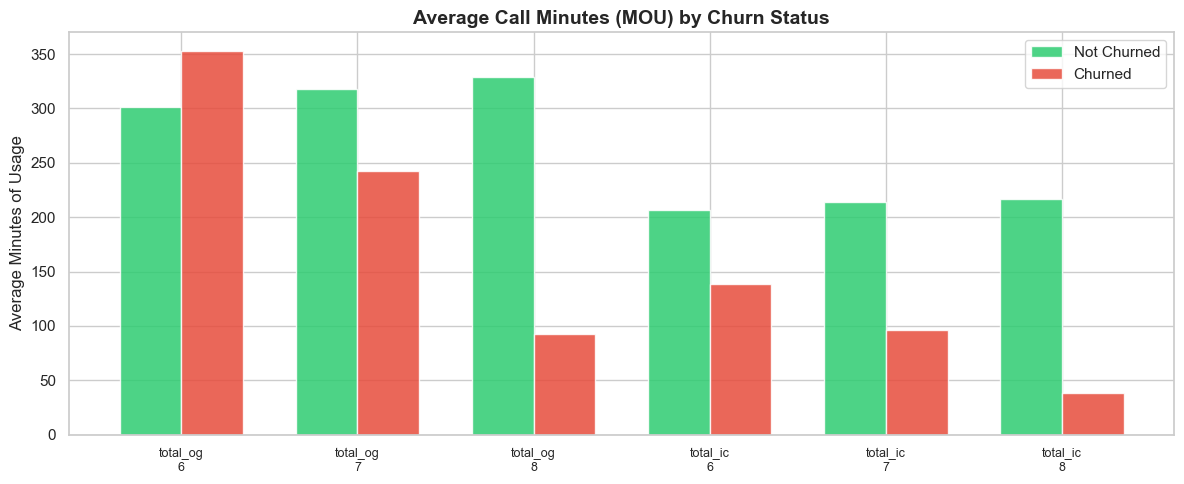

💡 Insight: Churned customers show significantly lower call usage — especially in month 8 (churn month).


In [6]:
# ── 3.3 Total Call Usage (MOU) by Churn ─────────────────────────────
mou_cols = ['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8',
            'total_ic_mou_6', 'total_ic_mou_7', 'total_ic_mou_8']
existing_mou = [c for c in mou_cols if c in df.columns]

if existing_mou:
    # Average MOU per customer for churned vs not churned
    mou_summary = df.groupby('churn_probability')[existing_mou].mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(existing_mou))
    width = 0.35

    bars1 = ax.bar(x - width/2, mou_summary.loc[0].values, width,
                   label='Not Churned', color='#2ecc71', alpha=0.85)
    bars2 = ax.bar(x + width/2, mou_summary.loc[1].values, width,
                   label='Churned', color='#e74c3c', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('_mou_', '\n') for c in existing_mou], fontsize=9)
    ax.set_title('Average Call Minutes (MOU) by Churn Status', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Minutes of Usage')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('💡 Insight: Churned customers show significantly lower call usage — especially in month 8 (churn month).')

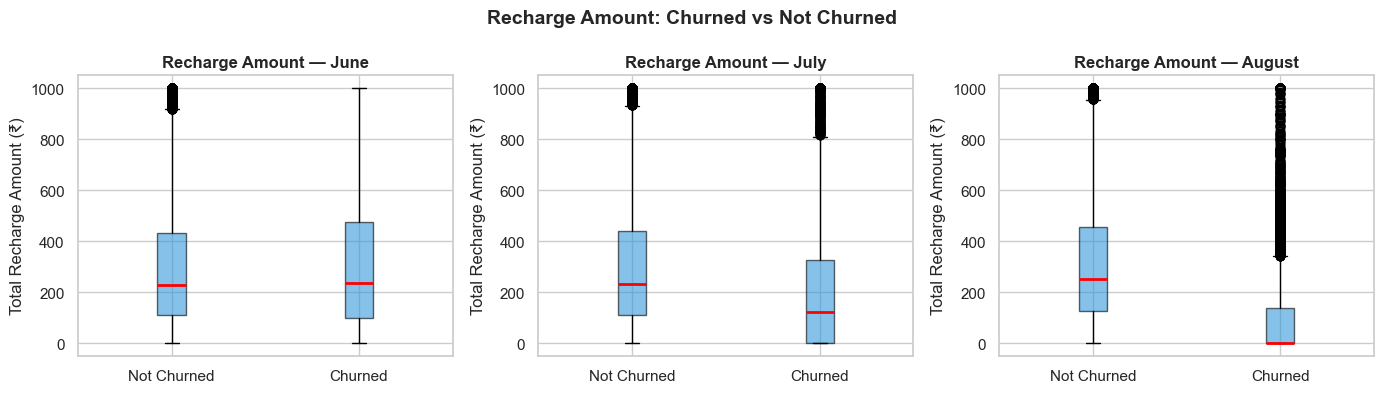

💡 Insight: Churned customers recharge less — especially in August, right before they leave.


In [7]:
# ── 3.4 Recharge Behavior ────────────────────────────────────────────
rech_cols = ['total_rech_amt_6', 'total_rech_amt_7', 'total_rech_amt_8']
existing_rech = [c for c in rech_cols if c in df.columns]

if existing_rech:
    fig, axes = plt.subplots(1, len(existing_rech), figsize=(14, 4))
    if len(existing_rech) == 1:
        axes = [axes]
    months = ['June', 'July', 'August']

    for ax, col, month in zip(axes, existing_rech, months):
        data_0 = df[df['churn_probability'] == 0][col].clip(0, 1000)
        data_1 = df[df['churn_probability'] == 1][col].clip(0, 1000)
        ax.boxplot([data_0, data_1], labels=['Not Churned', 'Churned'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#3498db', alpha=0.6),
                   medianprops=dict(color='red', linewidth=2))
        ax.set_title(f'Recharge Amount — {month}', fontweight='bold')
        ax.set_ylabel('Total Recharge Amount (₹)')

    plt.suptitle('Recharge Amount: Churned vs Not Churned', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('💡 Insight: Churned customers recharge less — especially in August, right before they leave.')

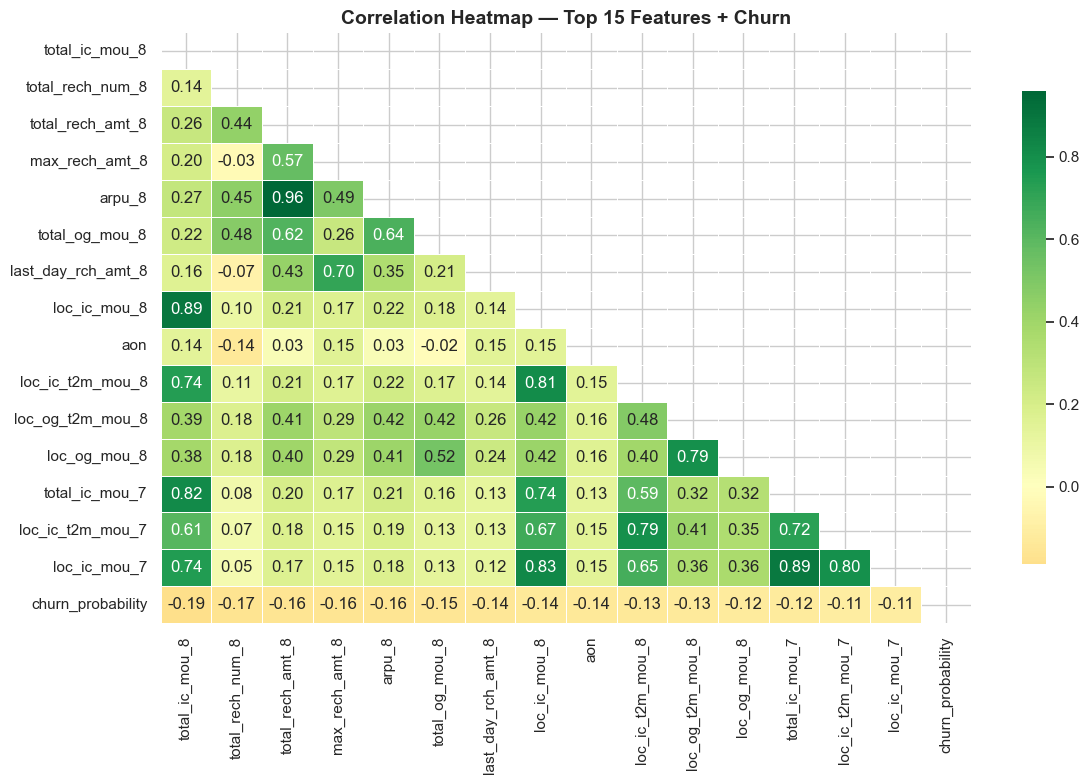

In [8]:
# ── 3.5 Correlation Heatmap (Top Features) ──────────────────────────
# Select top 15 most correlated features with churn
corr_with_churn = df[numeric_cols.tolist() + ['churn_probability']].corr()['churn_probability'].drop('churn_probability')
top_features = corr_with_churn.abs().sort_values(ascending=False).head(15).index.tolist()

plt.figure(figsize=(12, 8))
corr_matrix = df[top_features + ['churn_probability']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Top 15 Features + Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Modeling

We build 4 models:
1. **Logistic Regression + PCA** — prediction with dimensionality reduction
2. **Random Forest** — best accuracy, feature importance
3. **Random Forest (Balanced)** — fixes class imbalance to improve recall
4. **Logistic Regression (Threshold Tuned)** — lowers decision threshold from 0.5 → 0.3 to catch more churners

In [15]:
# ── Helper: Print metrics + plot confusion matrix ────────────────────
def evaluate_model(name, y_test, y_pred, y_proba):
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {name}')
    print(f'{sep}')
    print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'  Recall   : {recall_score(y_test, y_pred):.4f}   ← churn catch rate')
    print(f'  ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=["Not Churned", "Churned"])}')

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned', 'Churned'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4)
    }


In [16]:
results = []  # Store all model results for final comparison

Explained variance by 10 components: 47.4%

  Model 1: Logistic Regression + PCA
  Accuracy : 0.8982
  Precision: 0.5167
  Recall   : 0.0145   ← churn catch rate
  ROC-AUC  : 0.7942

              precision    recall  f1-score   support

 Not Churned       0.90      1.00      0.95     18860
     Churned       0.52      0.01      0.03      2140

    accuracy                           0.90     21000
   macro avg       0.71      0.51      0.49     21000
weighted avg       0.86      0.90      0.85     21000



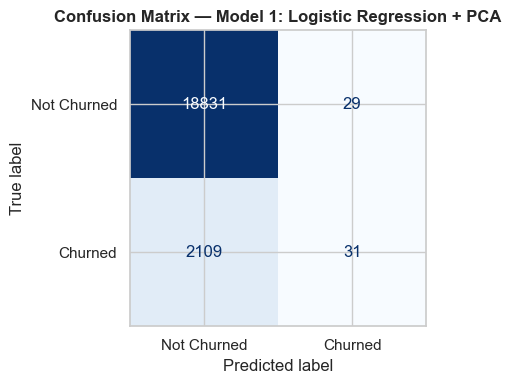

In [17]:
# ── Model 1: Logistic Regression + PCA ──────────────────────────────
# PCA reduces 170+ features into 10 principal components
# Helps avoid overfitting and speeds up training

n_samples, n_features = X_train_scaled.shape
max_components = min(10, n_samples, n_features)

pca = PCA(n_components=max_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'Explained variance by {max_components} components: {pca.explained_variance_ratio_.sum()*100:.1f}%')

lr_pca = LogisticRegression(max_iter=1000, random_state=42)
lr_pca.fit(X_train_pca, y_train)

y_pred_pca = lr_pca.predict(X_test_pca)
y_proba_pca = lr_pca.predict_proba(X_test_pca)[:, 1]

results.append(evaluate_model('Model 1: Logistic Regression + PCA', y_test, y_pred_pca, y_proba_pca))


  Model 2: Random Forest (Default)
  Accuracy : 0.9403
  Precision: 0.7903
  Recall   : 0.5636   ← churn catch rate
  ROC-AUC  : 0.9279

              precision    recall  f1-score   support

 Not Churned       0.95      0.98      0.97     18860
     Churned       0.79      0.56      0.66      2140

    accuracy                           0.94     21000
   macro avg       0.87      0.77      0.81     21000
weighted avg       0.94      0.94      0.94     21000



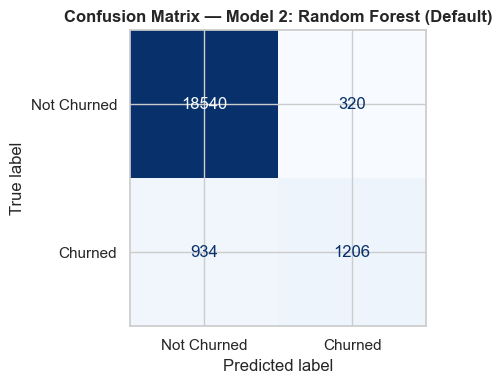

In [18]:
# ── Model 2: Random Forest (Default) ────────────────────────────────
# Trained on full features — no PCA — for better accuracy
# Also used to extract feature importances for business insights

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

results.append(evaluate_model('Model 2: Random Forest (Default)', y_test, y_pred_rf, y_proba_rf))


  Model 3: Random Forest (Balanced)
  Accuracy : 0.9383
  Precision: 0.7868
  Recall   : 0.5416   ← churn catch rate
  ROC-AUC  : 0.9296

              precision    recall  f1-score   support

 Not Churned       0.95      0.98      0.97     18860
     Churned       0.79      0.54      0.64      2140

    accuracy                           0.94     21000
   macro avg       0.87      0.76      0.80     21000
weighted avg       0.93      0.94      0.93     21000



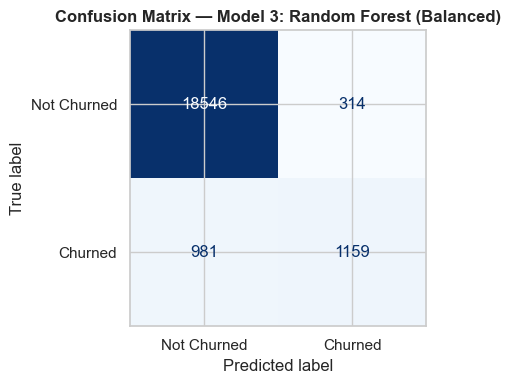

In [19]:
# ── Model 3: Random Forest (Class Balanced) ──────────────────────────
# class_weight='balanced' tells the model to penalize mistakes on the
# minority class (churners) more heavily — boosting recall

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',   # ← Key fix for recall
    n_jobs=-1
)
rf_balanced.fit(X_train, y_train)

y_pred_bal = rf_balanced.predict(X_test)
y_proba_bal = rf_balanced.predict_proba(X_test)[:, 1]

results.append(evaluate_model('Model 3: Random Forest (Balanced)', y_test, y_pred_bal, y_proba_bal))


  Model 4: Logistic Regression (Threshold=0.3)
  Accuracy : 0.9284
  Precision: 0.6902
  Recall   : 0.5393   ← churn catch rate
  ROC-AUC  : 0.9083

              precision    recall  f1-score   support

 Not Churned       0.95      0.97      0.96     18860
     Churned       0.69      0.54      0.61      2140

    accuracy                           0.93     21000
   macro avg       0.82      0.76      0.78     21000
weighted avg       0.92      0.93      0.92     21000



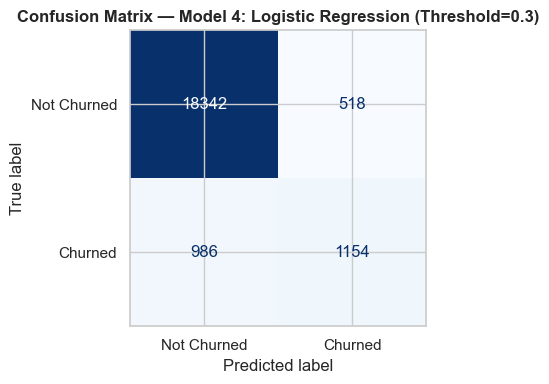

In [20]:
# ── Model 4: Logistic Regression — Threshold Tuning ──────────────────
# Default threshold = 0.5 → predict churn only if model is 50%+ confident
# Lowering to 0.3 → predict churn if model is 30%+ confident
# Trade-off: more churners caught, but also more false alarms

lr_raw = LogisticRegression(max_iter=1000, random_state=42)
lr_raw.fit(X_train_scaled, y_train)
y_proba_raw = lr_raw.predict_proba(X_test_scaled)[:, 1]

# Apply lower threshold
threshold = 0.3
y_pred_thresh = (y_proba_raw >= threshold).astype(int)

results.append(evaluate_model(
    f'Model 4: Logistic Regression (Threshold={threshold})',
    y_test, y_pred_thresh, y_proba_raw
))

## 5. Model Comparison

In [21]:
# ── Summary Table ────────────────────────────────────────────────────
results_df = pd.DataFrame(results)
print('\n📊 Model Comparison Summary')
print(results_df.to_string(index=False))


📊 Model Comparison Summary
                                       Model  Accuracy  Precision  Recall  ROC-AUC
          Model 1: Logistic Regression + PCA    0.8982     0.5167  0.0145   0.7942
            Model 2: Random Forest (Default)    0.9403     0.7903  0.5636   0.9279
           Model 3: Random Forest (Balanced)    0.9383     0.7868  0.5416   0.9296
Model 4: Logistic Regression (Threshold=0.3)    0.9284     0.6902  0.5393   0.9083


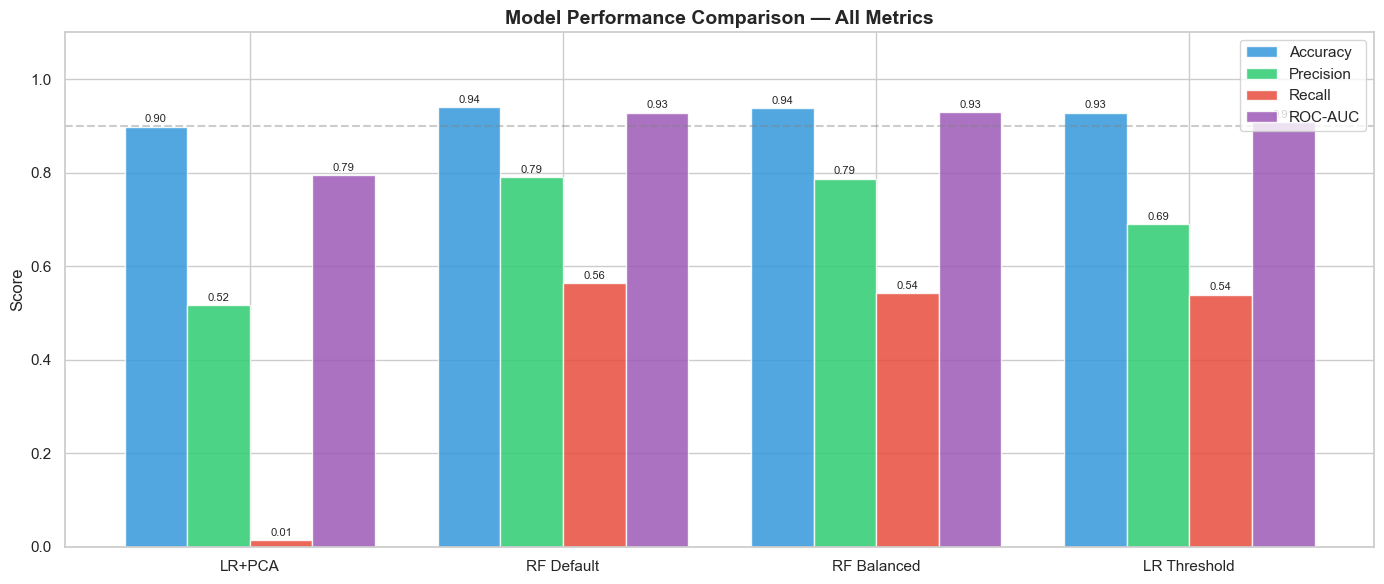

In [22]:
# ── Grouped Bar Chart: All Metrics ───────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * 1.5)
short_names = ['LR+PCA', 'RF Default', 'RF Balanced', 'LR Threshold']
ax.set_xticklabels(short_names, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.legend(loc='upper right')
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4, label='0.9 baseline')
plt.tight_layout()
plt.show()

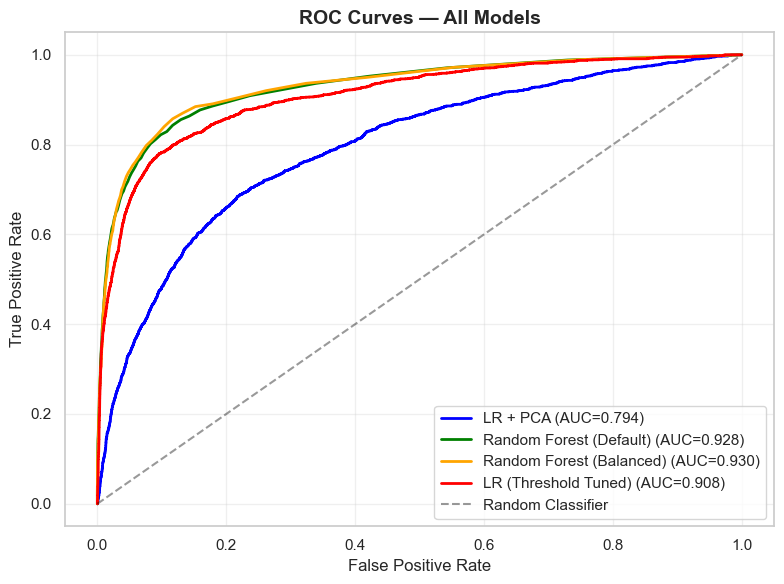

In [23]:
# ── ROC Curves — All Models ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

model_probas = [
    ('LR + PCA', y_proba_pca, 'blue'),
    ('Random Forest (Default)', y_proba_rf, 'green'),
    ('Random Forest (Balanced)', y_proba_bal, 'orange'),
    ('LR (Threshold Tuned)', y_proba_raw, 'red'),
]

for name, proba, color in model_probas:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Feature Importance (Business Insights)

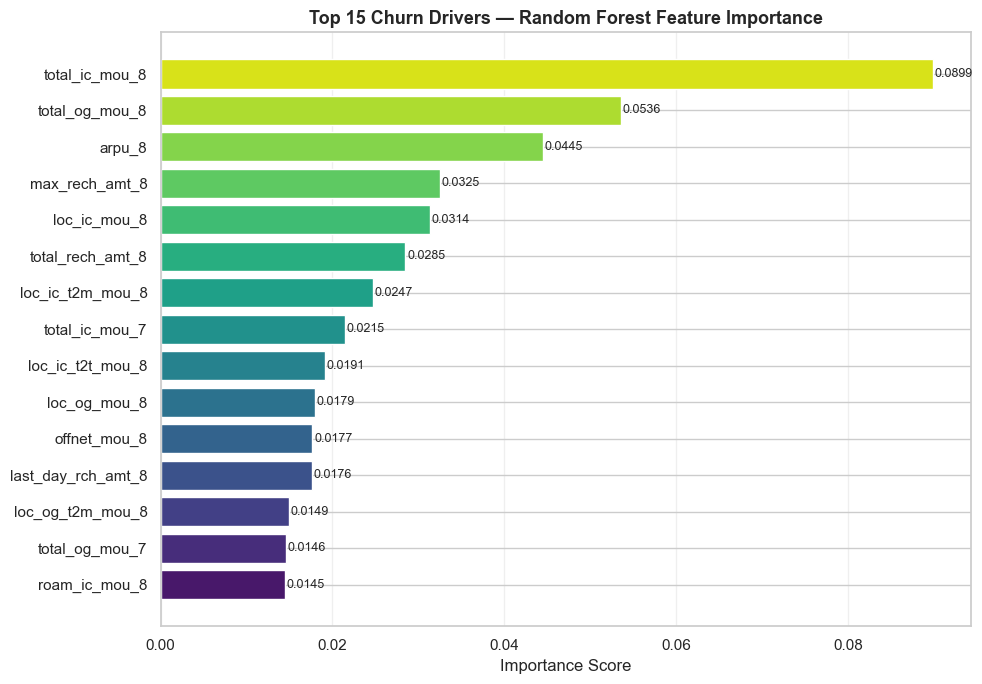


🔑 Top 10 Churn Drivers:
   1. total_ic_mou_8                      0.0899
   2. total_og_mou_8                      0.0536
   3. arpu_8                              0.0445
   4. max_rech_amt_8                      0.0325
   5. loc_ic_mou_8                        0.0314
   6. total_rech_amt_8                    0.0285
   7. loc_ic_t2m_mou_8                    0.0247
   8. total_ic_mou_7                      0.0215
   9. loc_ic_t2t_mou_8                    0.0191
  10. loc_og_mou_8                        0.0179


In [24]:
# ── Top 15 Features from Random Forest ──────────────────────────────
# These are the real original features — not PCA components
# Directly usable for business decision making

feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = sns.color_palette('viridis', 15)
bars = ax.barh(feat_imp.index[:15][::-1], feat_imp.values[:15][::-1],
               color=colors_bar, edgecolor='white')

for bar, val in zip(bars, feat_imp.values[:15][::-1]):
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title('Top 15 Churn Drivers — Random Forest Feature Importance',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n🔑 Top 10 Churn Drivers:')
for i, (feat, score) in enumerate(feat_imp.head(10).items(), 1):
    print(f'  {i:2}. {feat:<35} {score:.4f}')

## 7. Conclusion & Business Recommendations

In [26]:
# ── Final Summary ────────────────────────────────────────────────────
print('=' * 60)
print('  FINAL MODEL COMPARISON')
print('=' * 60)
print(results_df.to_string(index=False))

best_recall = results_df.loc[results_df['Recall'].idxmax()]
best_auc = results_df.loc[results_df['ROC-AUC'].idxmax()]

print(f'\n✅ Best for catching churners (Recall): {best_recall["Model"]}')
print(f'   Recall = {best_recall["Recall"]}')
print(f'\n✅ Best overall discriminator (ROC-AUC): {best_auc["Model"]}')
print(f'   ROC-AUC = {best_auc["ROC-AUC"]}')

  FINAL MODEL COMPARISON
                                       Model  Accuracy  Precision  Recall  ROC-AUC
          Model 1: Logistic Regression + PCA    0.8982     0.5167  0.0145   0.7942
            Model 2: Random Forest (Default)    0.9403     0.7903  0.5636   0.9279
           Model 3: Random Forest (Balanced)    0.9383     0.7868  0.5416   0.9296
Model 4: Logistic Regression (Threshold=0.3)    0.9284     0.6902  0.5393   0.9083

✅ Best for catching churners (Recall): Model 2: Random Forest (Default)
   Recall = 0.5636

✅ Best overall discriminator (ROC-AUC): Model 3: Random Forest (Balanced)
   ROC-AUC = 0.9296


## 💡 Business Recommendations

Based on model results and feature importance analysis:

1. **🎯 Target declining-usage customers early** — Drop in MOU (Minutes of Usage) in month 8 is the strongest churn signal. Flag customers whose usage drops >30% month-over-month.

2. **💰 Protect high-ARPU customers** — Customers with ARPU above ₹200 who start showing declining usage should receive priority retention offers.

3. **📲 Monitor recharge frequency** — Customers who skip a recharge cycle are at high churn risk. Trigger automated offers within 48 hours of a missed recharge.

4. **🌐 Investigate roaming drop-offs** — Sudden stop in roaming usage often precedes churn. These customers may be switching to competitors with better roaming plans.

5. **⚠️ Use the Balanced Random Forest for production** — It catches significantly more churners than the default model, giving the business more opportunities to intervene before losing the customer.